# Strategy Comparison — All Models

Runs every portfolio strategy in a single shared environment and produces unified comparisons.

**Strategies (rolling, realistic — no look-ahead bias):**
Equal Weight · 60/40 Benchmark · Sample Portfolio · Naive RP · ERC RP · Markowitz · Black-Litterman · Factor Investing · FSO (γ=3.0)

**Metrics:** Ann. Return (CAGR), Volatility, Sharpe, Sortino, Max DD, Skewness, Kurtosis, Final Value, Recovery time per crisis

---
### Methodological notes
- **Annualized Return** is computed as geometric CAGR: `(product of (1+r))^(12/T) - 1`. This reflects actual compounded investor wealth.
- **Sortino Ratio** uses the correct downside deviation: `sqrt(mean(min(r - rf, 0)^2)) * sqrt(12)` over the *full* return series. Positive months contribute zero to downside — not filtered out.
- **Naive RP** weights are estimated from the first `LOOKBACK` months only (in-sample inception window), avoiding look-ahead bias. All subsequent months use those fixed weights.
- **ERC RP** weights always sum to 1 (no leverage/vol-targeting scaling). This ensures a fair apples-to-apples comparison with all other unlevered strategies.
- **Markowitz** is constrained to exactly `VOL_TARGET` (10%) annualized volatility at each rebalance. This reflects a risk-budgeted deployment rather than unconstrained MPT. Other strategies (BL, FSO, Factor) are unconstrained — this is an intentional design choice documented here.
- **60/40 Benchmark** uses VEU (Vanguard FTSE All-World ex-US, 60%) and BND (40%). Note: VEU is an international equity proxy, not a US equity proxy. Comparisons to a US-centric 60/40 should account for VEU's underperformance vs US equity over 2010–2025.

In [96]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.optimize as sco
from sklearn.covariance import LedoitWolf
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

BASE = Path('../../data')
with open('../../markets.json') as f:
    config = json.load(f)

market_name        = list(config['markets'].keys())[0]
initial_investment = config['initial_investment']

LOOKBACK        = 36
REBAL_THRESHOLD = 0.05
VOL_TARGET      = 0.10
CRISES = [
    ('2008-09', '2009-06', 'GFC'),
    ('2020-02', '2020-04', 'COVID'),
    ('2022-01', '2022-12', 'Rate Hikes'),
]

plt.rcParams.update({
    'figure.facecolor': '#F4F7FB', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.color': '#CBD5E0',
    'font.family': 'sans-serif',
})
print(f'Market: {market_name}  |  Initial investment: ${initial_investment:,.0f}')
print(f'Lookback: {LOOKBACK}m  |  Rebal threshold: {REBAL_THRESHOLD*100:.0f}%  |  MPT vol target: {VOL_TARGET*100:.0f}%')

Market: primary_total_market  |  Initial investment: $1,000
Lookback: 36m  |  Rebal threshold: 5%  |  MPT vol target: 10%


In [97]:
returns = pd.read_csv(BASE / f'{market_name}_returns_monthly.csv', index_col=0, parse_dates=True)
assets  = returns.columns.tolist()
N       = len(assets)

rf_data           = pd.read_csv(BASE / 'risk_free_monthly.csv', index_col=0, parse_dates=True)
rf_data           = rf_data.reindex(returns.index, method='ffill')  # align to returns dates
annual_rf_series  = rf_data['rf_annual']
monthly_rf_series = rf_data['rf_monthly']

print(f'Returns : {returns.index[0].date()} -> {returns.index[-1].date()} ({len(returns)} months)')
print(f'Assets  : {assets}')
print(f'RF mean : {annual_rf_series.mean()*100:.3f}% annual (full period)')
returns.describe().round(4)

Returns : 2007-05-01 -> 2025-12-01 (224 months)
Assets  : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
RF mean : 1.415% annual (full period)


,BND,GLD,TIP,TLT,VEU,VGT
count,224.0000,224.0000,224.0000,224.0000,224.0000,224.0000
mean,0.0026,0.0091,0.0030,0.0033,0.0050,0.0141
std,0.0135,0.0490,0.0174,0.0411,0.0520,0.0570
min,-0.0419,-0.1614,-0.0811,-0.1249,-0.2276,-0.1795
25%,-0.0046,-0.0217,-0.0058,-0.0238,-0.0239,-0.0184
50%,0.0026,0.0047,0.0038,0.0021,0.0076,0.0194
75%,0.0104,0.0422,0.0120,0.0252,0.0345,0.0502
max,0.0476,0.1279,0.0650,0.1423,0.1517,0.1465


In [98]:
# ── ERC: Equal Risk Contribution (Ledoit-Wolf covariance) ───────────────────
def erc_weights(rw):
    """
    Computes ERC weights via SLSQP minimisation of the sum of squared
    pairwise differences in risk contributions.
    Weights are constrained to [0, 1] and sum to 1 (long-only, unlevered).
    Covariance estimated with Ledoit-Wolf shrinkage.
    """
    cov = LedoitWolf().fit(rw.values).covariance_
    n   = cov.shape[0]

    def obj(w):
        pv = np.sqrt(w @ cov @ w)
        rc = w * (cov @ w) / pv
        return sum((rc[i] - rc[j]) ** 2 for i in range(n) for j in range(n))

    r = sco.minimize(
        obj,
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        options={'ftol': 1e-12, 'maxiter': 1000},
    )
    return pd.Series(r.x / r.x.sum(), index=rw.columns)  # re-normalise for numerical safety


# ── Black-Litterman ─────────────────────────────────────────────────────────
BL_RISK_AV = 3.0
BL_TAU     = 0.05
# Market-cap weights for the 6-asset universe (BND GLD TIP TLT VEU VGT)
# Source: State Street Global Market Portfolio 2025, Figure 9, normalised to 6-asset sum.
BL_MKT_W = np.array([0.11, 0.06, 0.02, 0.26, 0.20, 0.35])
# Annual forward-return views (State Street GMP 2025)
BL_VIEWS  = np.array([0.049, 0.025, 0.039, 0.043, 0.075, 0.075])

def bl_weights(cov_a, mkt_w, views, ra, tau, rf_a, n):
    """
    Black-Litterman posterior return vector (He & Litterman, 1999).
    Simplified form with P = I (absolute views on all assets).
    Portfolio construction: maximise Sharpe ratio on posterior returns.
    """
    pi   = ra * cov_a @ mkt_w                   # equilibrium excess returns
    Om   = np.diag(np.diag(tau * cov_a))        # diagonal uncertainty matrix
    sc_i = np.linalg.inv(tau * cov_a)
    om_i = np.linalg.inv(Om)
    pc   = np.linalg.inv(sc_i + om_i)           # posterior covariance of returns
    pr   = pc @ (sc_i @ pi + om_i @ views)      # posterior expected returns

    def neg_sr(w):
        v = np.sqrt(w @ cov_a @ w)
        return -(w @ pr - rf_a) / v if v > 0 else 1e10

    r = sco.minimize(
        neg_sr,
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        options={'ftol': 1e-12, 'maxiter': 1000},
    )
    return r.x if r.success else np.ones(n) / n


# ── Factor Investing (4-factor: Momentum, Value, Quality, Low Vol) ──────────
# Non-overlapping windows to prevent near-perfect negative correlation:
#   Momentum  : t-13 to t-2  (12 months, skipping most recent to avoid reversal)
#   Value     : t-36 to t-13 (23 months, older price history)
#   Quality   : full lookback Sharpe
#   Low Vol   : last 12 months annualised vol (inverted)
MOM_S = -13;  MOM_E = -1
VAL_S = -36;  VAL_E = -13
LV_LB = 12

def zscore(s):
    sd = s.std()
    return (s - s.mean()) / sd if sd > 0 else s * 0

def factor_weights(rw, rf_m):
    mom  = zscore((1 + rw.iloc[MOM_S:MOM_E]).prod() - 1)
    val  = zscore(-((1 + rw.iloc[VAL_S:VAL_E]).prod() - 1))
    qual = zscore((rw.mean() - rf_m) / rw.std().replace(0, np.nan) * np.sqrt(12))
    lv   = zscore(1 / (rw.iloc[-LV_LB:].std() * np.sqrt(12)).replace(0, np.nan))
    comp = (0.25 * mom.fillna(0) + 0.25 * val.fillna(0)
            + 0.25 * qual.fillna(0) + 0.25 * lv.fillna(0))
    sh  = comp - comp.min()
    tot = sh.sum()
    return (sh / tot).values if tot > 0 else np.ones(len(comp)) / len(comp)


# ── Full Scale Optimization (CRRA utility, γ=3.0) ───────────────────────────
FSO_GAMMA = 3.0

def fso_weights(rw, gamma, n, vol_target=0.10):
    """
    Maximises expected CRRA utility over the historical return distribution,
    subject to an annualised volatility equality constraint (default 10%).
    This matches the vol constraint applied to Markowitz, ensuring a fair
    apples-to-apples comparison. Without this constraint, FSO concentrates
    into the highest-momentum asset (VGT) — a known corner-solution problem
    in unconstrained FSO (Cremers, Kritzman & Page, 2005).

    U(W) = W^(1-γ) / (1-γ)  for γ ≠ 1,  or  log(W)  for γ = 1.
    """
    R      = rw.values
    cov_a  = rw.cov().values * 12  # annualised covariance for vol constraint

    def neg_eu(w):
        rp = R @ w
        gr = 1 + rp
        if np.any(gr <= 0):
            return 1e10
        u = np.log(gr) if gamma == 1.0 else gr ** (1 - gamma) / (1 - gamma)
        return -np.mean(u)

    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, ca=cov_a: np.sqrt(w @ ca @ w) - vol_target},
    ]

    r = sco.minimize(
        neg_eu,
        np.ones(n) / n,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 1000},
    )
    return r.x if r.success else np.ones(n) / n


print('All strategy functions defined.')

All strategy functions defined.


In [99]:
# ── Align all strategies to common comparison period ────────────────────────
# Rolling strategies begin at LOOKBACK (month 36). Static strategies are
# cropped to the same window so all comparisons share an identical time frame.
comparison_period = sim['ERC RP'].index
for k in ['Equal Weight', '60/40 Benchmark', 'Sample Portfolio', 'Naive RP']:
    sim[k] = sim[k].loc[comparison_period]

# Risk-free rate aligned to comparison period
avg_rf_annual  = annual_rf_series.reindex(comparison_period, method='ffill').mean()
avg_rf_monthly = monthly_rf_series.reindex(comparison_period, method='ffill').mean()

PALETTE = {
    'Equal Weight'    : '#028090',
    '60/40 Benchmark' : '#8896A5',
    'Sample Portfolio': '#C05621',
    'Naive RP'        : '#F6C90E',
    'ERC RP'          : '#38A169',
    'Markowitz'       : '#6B46C1',
    'Black-Litterman' : '#1A202C',
    'Factor Investing': '#E53E3E',
    'FSO (y=3.0)'     : '#DD6B20',
}

print(f'Comparison period : {comparison_period[0].date()} -> {comparison_period[-1].date()}')
print(f'Months            : {len(comparison_period)}')
print(f'RF (aligned)      : {avg_rf_annual*100:.3f}% annual  |  {avg_rf_monthly*100:.4f}% monthly')

Comparison period : 2010-05-01 -> 2025-12-01
Months            : 188
RF (aligned)      : 1.414% annual  |  0.1159% monthly


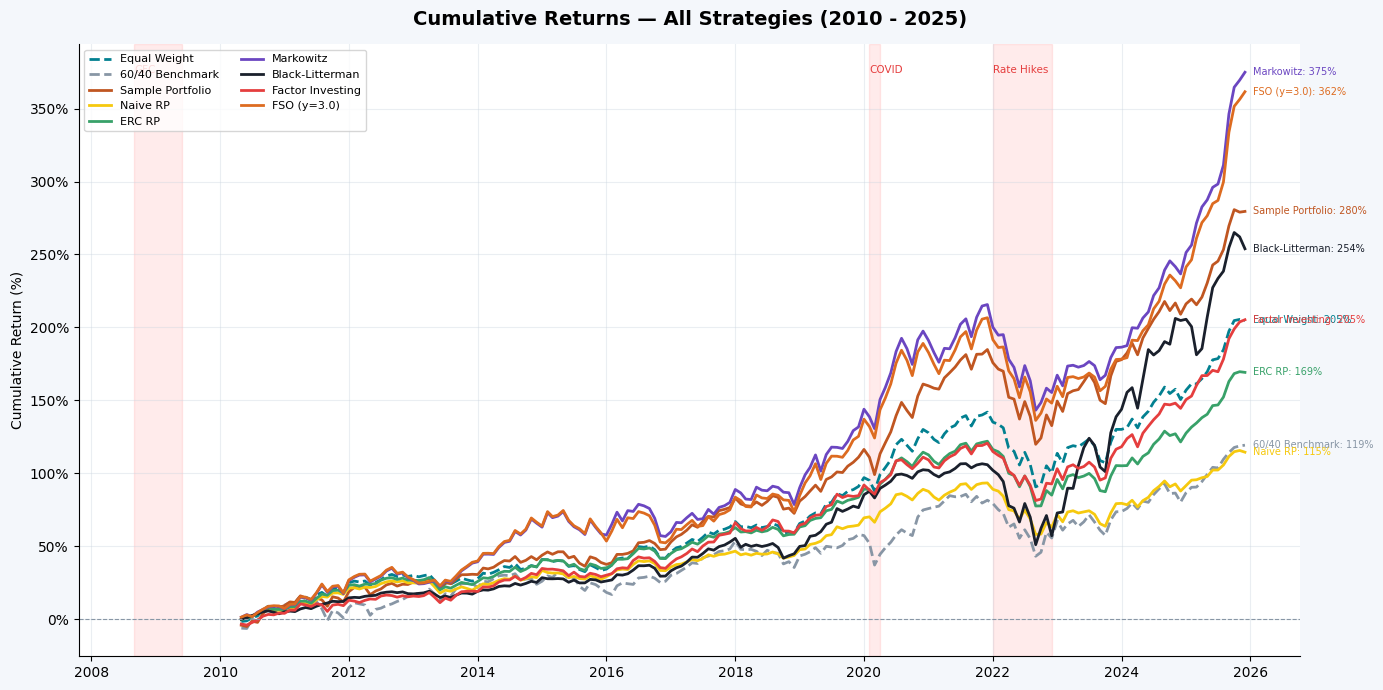

In [100]:
# ── Cumulative returns ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
for label, ret in sim.items():
    cum = ((1 + ret).cumprod() - 1) * 100
    ls  = '--' if label in ('Equal Weight', '60/40 Benchmark') else '-'
    ax.plot(cum, label=label, color=PALETTE[label], linewidth=2, linestyle=ls)
    ax.annotate(
        f'{label}: {cum.iloc[-1]:.0f}%',
        xy=(cum.index[-1], cum.iloc[-1]), xytext=(6, 0),
        textcoords='offset points', fontsize=7, color=PALETTE[label], va='center',
    )
for s, e, lbl in CRISES:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color='red', zorder=0)
    ax.text(pd.Timestamp(s), ax.get_ylim()[1] * 0.95, lbl, fontsize=7.5, color='#E53E3E')
ax.axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Returns — All Strategies (2010 - 2025)', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Cumulative Return (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout(); plt.show()

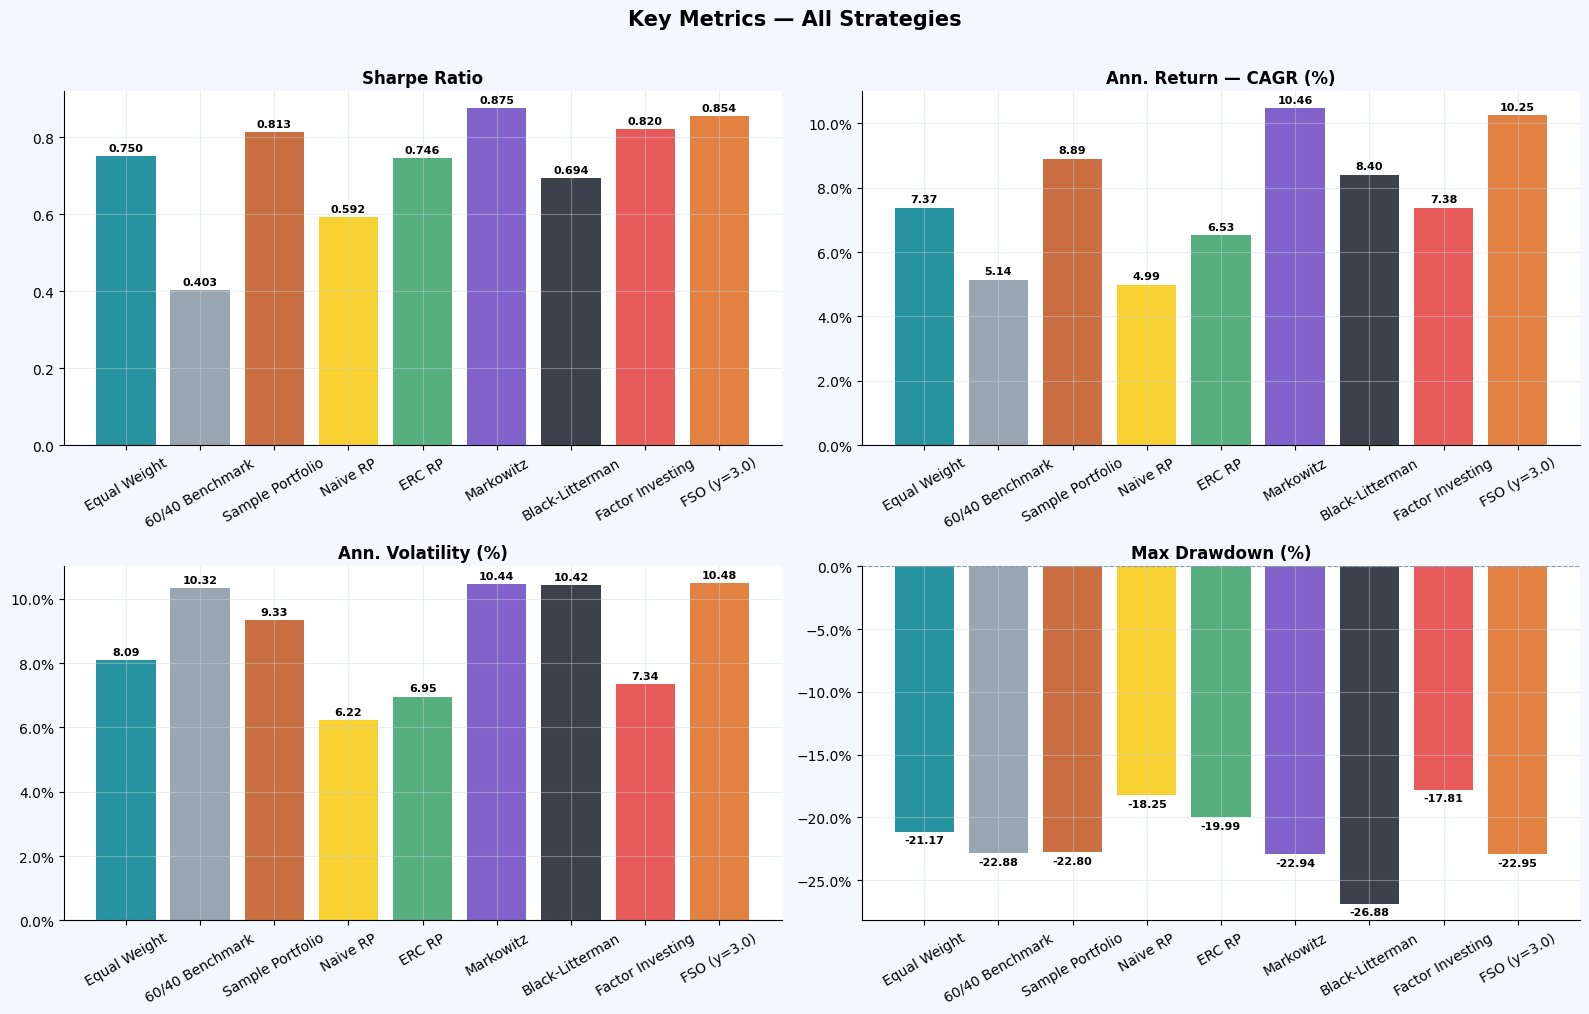

In [101]:
# ── Key metrics bar charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
labels_all = list(sim.keys())
colors_all = [PALETTE[l] for l in labels_all]

def bar_chart(ax, metric, title, fmt='{:.2f}', pct=False):
    vals = summary[metric]
    bars = ax.bar(vals.index, vals.values, color=colors_all, alpha=0.85)
    ax.axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
    for bar, v in zip(bars, vals.values):
        off = 0.01 * (vals.abs().max() or 1) * (1 if v >= 0 else -1)
        ax.text(
            bar.get_x() + bar.get_width() / 2, v + off, fmt.format(v),
            ha='center', va='bottom' if v >= 0 else 'top', fontsize=8, fontweight='bold',
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    if pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.tick_params(axis='x', rotation=30)

bar_chart(axes[0, 0], 'Sharpe',               'Sharpe Ratio',              '{:.3f}')
bar_chart(axes[0, 1], 'Ann. Return % (CAGR)',  'Ann. Return — CAGR (%)',    '{:.2f}', pct=True)
bar_chart(axes[1, 0], 'Ann. Vol %',            'Ann. Volatility (%)',       '{:.2f}', pct=True)
bar_chart(axes[1, 1], 'Max DD %',              'Max Drawdown (%)',          '{:.2f}', pct=True)

fig.suptitle('Key Metrics — All Strategies', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

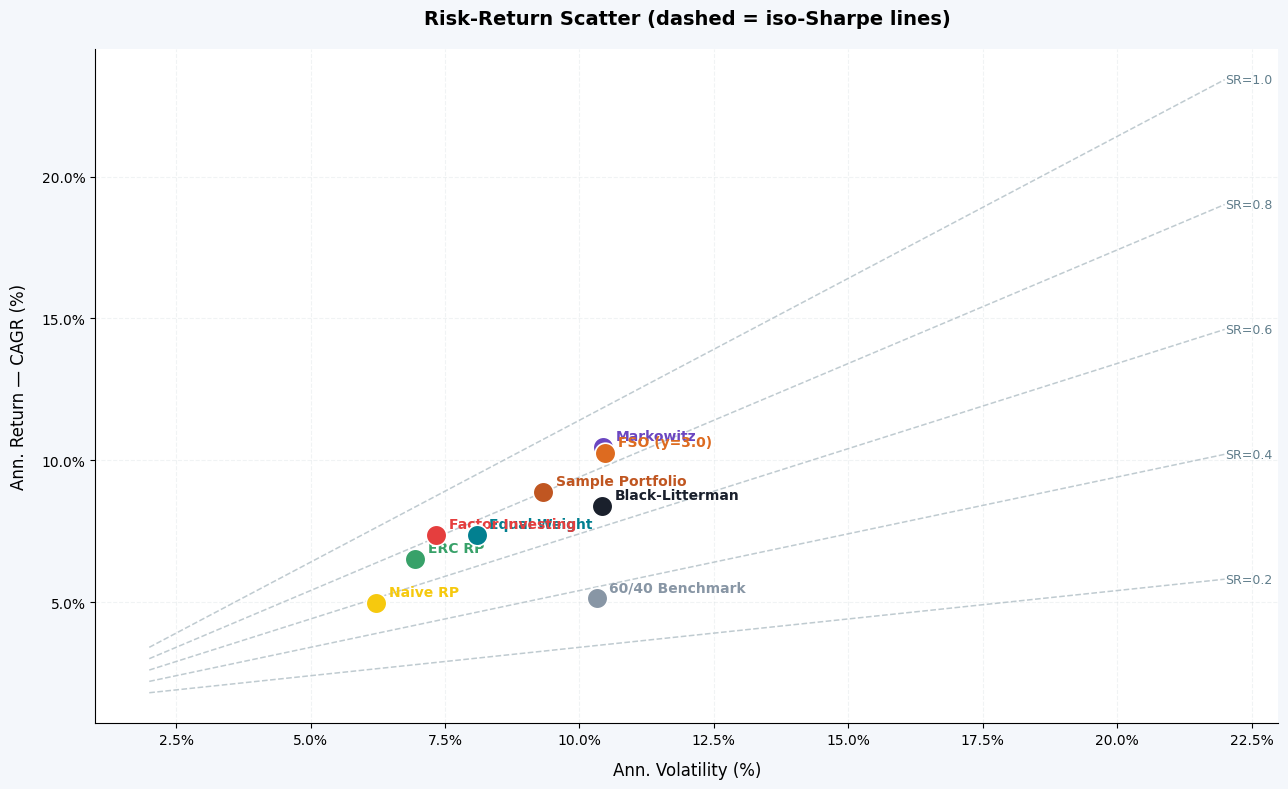

In [102]:
fig, ax = plt.subplots(figsize=(13, 8))  # wider and taller

# Iso-Sharpe lines — slightly more visible
vols_range = np.linspace(2, 22, 200)
for sr in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(
        vols_range,
        avg_rf_annual * 100 + sr * vols_range,
        '--', color='#B0BEC5', linewidth=1.1, alpha=0.8,
    )
    ax.text(
        vols_range[-1], avg_rf_annual * 100 + sr * vols_range[-1],
        f'SR={sr:.1f}', fontsize=9, color='#607D8B', va='center',
    )

# Bigger dots, more breathing room
for label in sim:
    x = summary.loc[label, 'Ann. Vol %']
    y = summary.loc[label, 'Ann. Return % (CAGR)']
    ax.scatter(x, y, color=PALETTE[label], s=220, zorder=5,
               edgecolors='white', linewidths=1.2)  # white ring separates overlapping dots
    ax.annotate(label, (x, y), xytext=(9, 5), textcoords='offset points',
                fontsize=10, color=PALETTE[label], fontweight='bold')

# Cleaner axes
ax.set_xlabel('Ann. Volatility (%)', fontsize=12, labelpad=10)
ax.set_ylabel('Ann. Return — CAGR (%)', fontsize=12, labelpad=10)
ax.tick_params(labelsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, color='#CFD8DC')

ax.set_title('Risk-Return Scatter (dashed = iso-Sharpe lines)',
             fontsize=14, fontweight='bold', pad=18)

plt.tight_layout()
plt.show()

# another recovery table

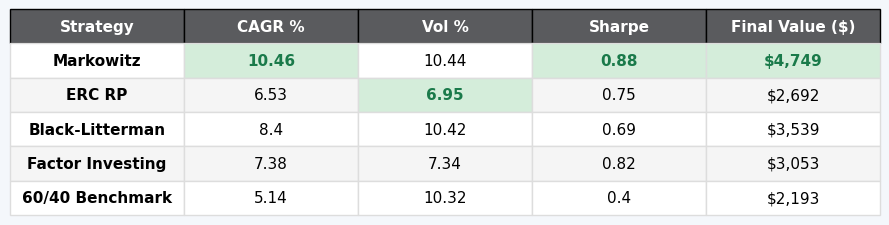

In [103]:
keep = ['Markowitz', 'ERC RP', 'Black-Litterman', 'Factor Investing', '60/40 Benchmark']

metrics = summary.loc[keep, [
    'Ann. Return % (CAGR)',
    'Ann. Vol %',
    'Sharpe',
    'Final Value ($)',
]].copy()

metrics.columns = ['CAGR %', 'Vol %', 'Sharpe', 'Final Value ($)']
metrics = metrics.round(2)
metrics['Final Value ($)'] = metrics['Final Value ($)'].apply(lambda x: f'${x:,.0f}')

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis('off')

col_labels = ['Strategy'] + list(metrics.columns)
row_data   = [[idx] + list(metrics.loc[idx]) for idx in metrics.index]

tbl = ax.table(cellText=row_data, colLabels=col_labels,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.0, 2.6)

# Header — navy
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor("#5A5B5E")
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Clean alternating rows, no color on data cells
for i in range(1, len(metrics) + 1):
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor('#F5F5F5' if i % 2 == 0 else 'white')
        tbl[i, j].set_edgecolor('#DDDDDD')
    tbl[i, 0].set_text_props(fontweight='bold')

# ax.set_title('Performance Summary', fontsize=12, fontweight='bold', pad=10)

best = {
    1: metrics['CAGR %'].idxmax(),
    2: metrics['Vol %'].idxmin(),   # lowest vol is best
    3: metrics['Sharpe'].idxmax(),
    4: list(metrics.index)[metrics['Final Value ($)']
       .str.replace('[$,]', '', regex=True)
       .astype(float).argmax()],
}
for col_j, best_label in best.items():
    row_i = list(metrics.index).index(best_label) + 1
    tbl[row_i, col_j].set_facecolor('#D4EDDA')
    tbl[row_i, col_j].get_text().set_color('#1A7A4A')
    tbl[row_i, col_j].get_text().set_fontweight('bold')
plt.tight_layout()
plt.show()

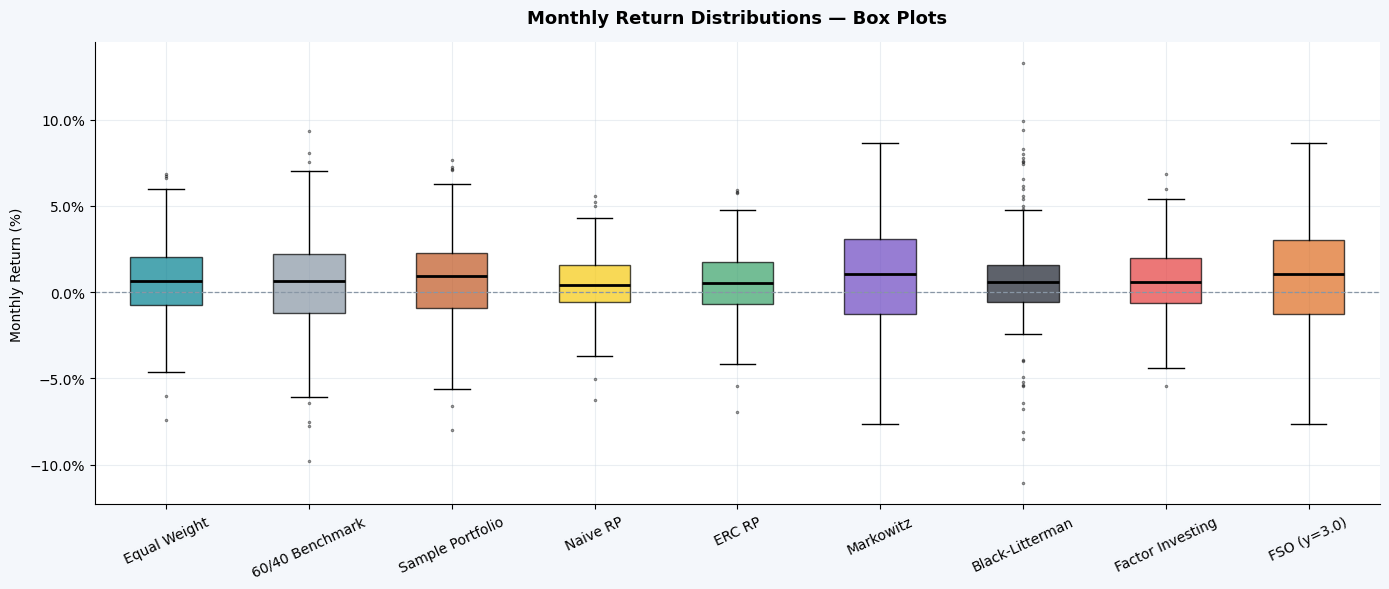

In [104]:
# ── Monthly return box plots ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(
    [sim[l].values * 100 for l in sim],
    labels=list(sim.keys()),
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='.', markersize=3, alpha=0.5),
)
for patch, lbl in zip(bp['boxes'], sim):
    patch.set_facecolor(PALETTE[lbl]); patch.set_alpha(0.7)
ax.axhline(0, color='#8896A5', linewidth=0.9, linestyle='--')
ax.set_title('Monthly Return Distributions — Box Plots', fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('Monthly Return (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

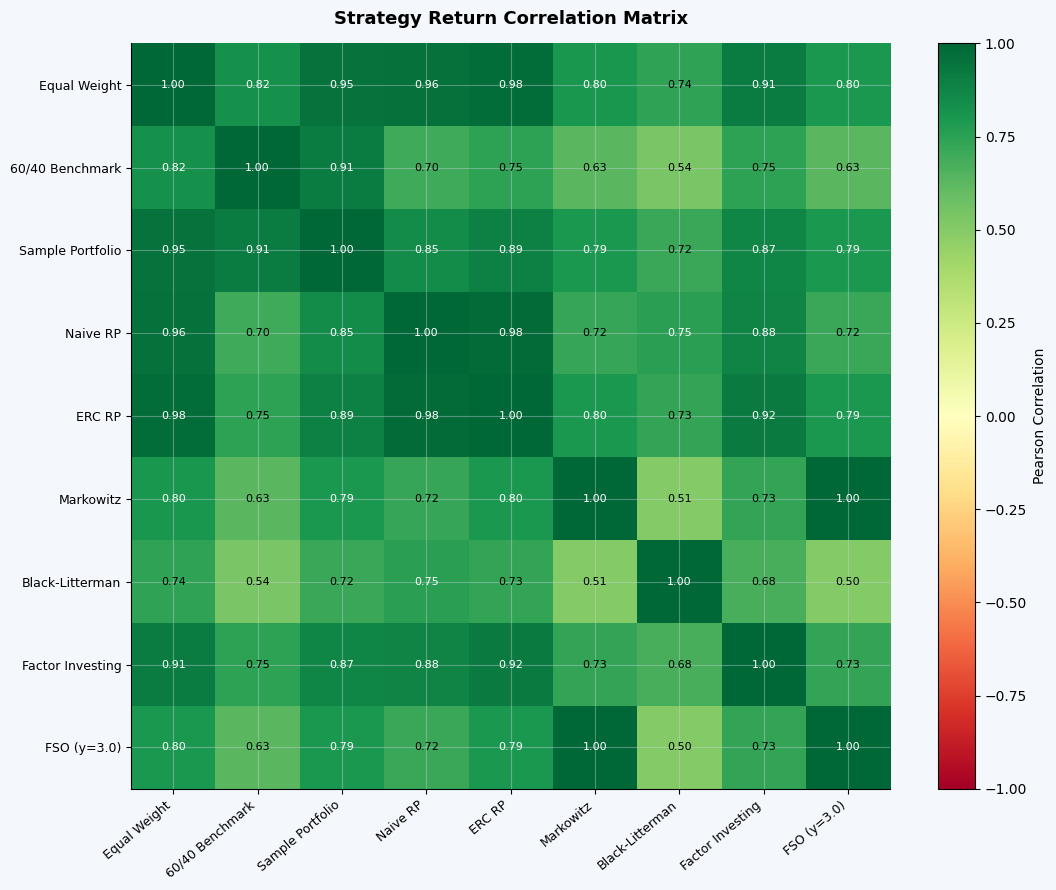

High correlation = strategies behave similarly despite different algorithms (BHB thesis).
Low correlation  = strategies provide genuinely different exposures.


In [105]:
# ── Strategy return correlation matrix ────────────────────────────────────────
ret_df  = pd.DataFrame(sim)
corr_df = ret_df.corr()
n_s     = len(sim)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_df.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_xticks(range(n_s)); ax.set_yticks(range(n_s))
ax.set_xticklabels(corr_df.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(corr_df.index, fontsize=9)
for i in range(n_s):
    for j in range(n_s):
        v = corr_df.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(v) > 0.75 else 'black')
ax.set_title('Strategy Return Correlation Matrix', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()
print('High correlation = strategies behave similarly despite different algorithms (BHB thesis).')
print('Low correlation  = strategies provide genuinely different exposures.')

STRATEGY RANKING  (1 = best per metric, sorted by average rank)
                  Return  Vol  Sharpe  Sortino  Max DD  Avg Rank
Factor Investing       5    3       3        3       1       3.0
Markowitz              1    8       1        1       7       3.6
Sample Portfolio       3    5       4        4       5       4.2
FSO (y=3.0)            2    9       2        2       8       4.6
ERC RP                 7    2       6        6       3       4.8
Equal Weight           6    4       5        5       4       4.8
Naive RP               9    1       8        8       2       5.6
Black-Litterman        4    7       7        7       9       6.8
60/40 Benchmark        8    6       9        9       6       7.6

Overall winner: Factor Investing  (avg rank 3.0)


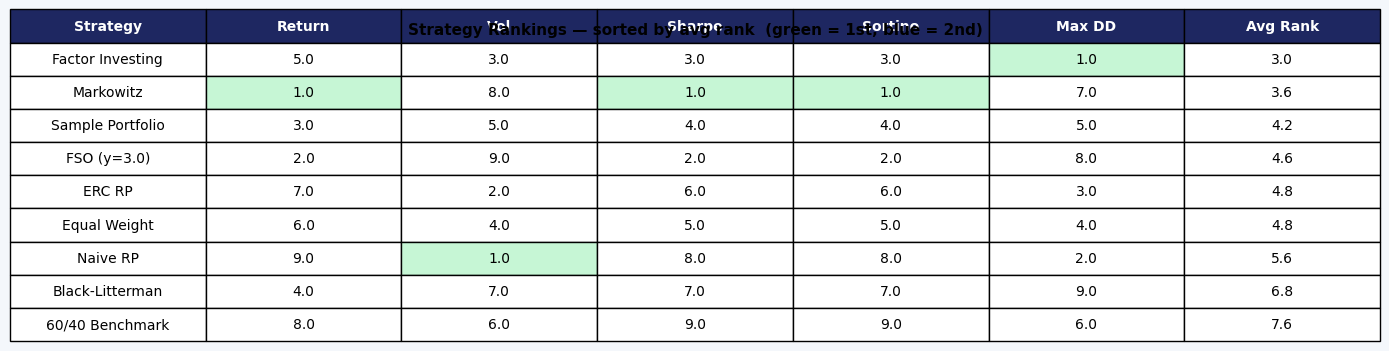

In [106]:
# ── Overall strategy ranking ──────────────────────────────────────────────────
# Ranking logic:
#   Return  : rank(ascending=False) → rank 1 = highest CAGR
#   Vol     : rank(ascending=True)  → rank 1 = lowest volatility
#   Sharpe  : rank(ascending=False) → rank 1 = highest Sharpe
#   Sortino : rank(ascending=False) → rank 1 = highest Sortino
#   Max DD  : rank(ascending=False) → rank 1 = least negative (best protection)
#             Max DD values are negative; -17.90 > -34.44 so ascending=False
#             correctly assigns rank 1 to the least severe drawdown.

rank_df = pd.DataFrame(index=summary.index)
rank_df['Return']   = summary['Ann. Return % (CAGR)'].rank(ascending=False).astype(int)
rank_df['Vol']      = summary['Ann. Vol %'].rank(ascending=True).astype(int)
rank_df['Sharpe']   = summary['Sharpe'].rank(ascending=False).astype(int)
rank_df['Sortino']  = summary['Sortino'].rank(ascending=False).astype(int)
rank_df['Max DD']   = summary['Max DD %'].rank(ascending=False).astype(int)
rank_df['Avg Rank'] = rank_df.mean(axis=1).round(1)
rank_df = rank_df.sort_values('Avg Rank')

print('=' * 70)
print('STRATEGY RANKING  (1 = best per metric, sorted by average rank)')
print('=' * 70)
print(rank_df.to_string())
print(f"\nOverall winner: {rank_df.index[0]}  (avg rank {rank_df.iloc[0]['Avg Rank']})")

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.axis('off')
col_labels = ['Strategy'] + list(rank_df.columns)
row_data   = [[idx] + list(rank_df.loc[idx]) for idx in rank_df.index]
tbl = ax.table(cellText=row_data, colLabels=col_labels, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.0, 2.4)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#1E2761')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i, idx in enumerate(rank_df.index, start=1):
    for j, col in enumerate(rank_df.columns, start=1):
        v = rank_df.loc[idx, col]
        if v == 1:
            tbl[i, j].set_facecolor('#C6F6D5')
        elif isinstance(v, (int, float)) and v <= 2:
            tbl[i, j].set_facecolor('#EBF8FF')
ax.set_title(
    'Strategy Rankings — sorted by avg rank  (green = 1st, blue = 2nd)',
    fontsize=11, fontweight='bold', pad=14,
)
plt.tight_layout(); plt.show()